In [ ]:
#Montando o Drive com os dados, utilizo o google drive para armazenar o arquivo csv, mas pode ser usado a pasta dados dentro do colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#parâmetros
CARGO = "Deputado Federal"   # ex.: "GOVERNADOR", "SENADOR", "DEPUTADO FEDERAL"
UF = "SP", "RJ", "MG", "ES"               # None = Brasil inteiro; ou a sigla da UF, ex.: "SP", "BA", "MG"
ANO_ELEICAO = 2026

In [ ]:
#Preparação do ambiente
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('dados', exist_ok=True)

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option("display.float_format", "{:,.2f}".format)

nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')

arquivo = f"/content/dados/despesas_contratadas_candidatos_2026_BRASIL.csv"
df_dc = pd.read_csv(arquivo, sep=';', encoding='latin1', decimal=',')
print(f"Carregado: {arquivo}  ->  {df_dc.shape[0]} registros, {df_dc.shape[1]} colunas")
# Força a exibição do primeiro DataFrame
display(df_dc.head())

# arquivo de despesas pagas não foi utilizado pela dificuldade em relacionar com o despesas contratadas, e por não ser o alvo nesse momento
nome_uf = UF if UF is not None else 'BRASIL'
arquivo_2 = f"/content/dados/despesas_pagas_candidatos_2026_BRASIL.csv"
df_dp = pd.read_csv(arquivo_2, sep=';', encoding='latin1', decimal=',')
print(f"Carregado: {arquivo_2}  ->  {df_dp.shape[0]} registros, {df_dp.shape[1]} colunas")
display(df_dp.head())

Carregado: /content/dados/despesas_contratadas_candidatos_2026_BRASIL.csv  ->  742385 registros, 53 colunas


,DT_GERACAO,HH_GERACAO,AA_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,ST_TURNO,TP_PRESTACAO_CONTAS,DT_PRESTACAO_CONTAS,SQ_PRESTADOR_CONTAS,SG_UF,SG_UE,NM_UE,NR_CNPJ_PRESTADOR_CONTA,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NR_CPF_CANDIDATO,NR_CPF_VICE_CANDIDATO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,CD_TIPO_FORNECEDOR,DS_TIPO_FORNECEDOR,CD_CNAE_FORNECEDOR,DS_CNAE_FORNECEDOR,NR_CPF_CNPJ_FORNECEDOR,NM_FORNECEDOR,NM_FORNECEDOR_RFB,CD_ESFERA_PART_FORNECEDOR,DS_ESFERA_PART_FORNECEDOR,SG_UF_FORNECEDOR,CD_MUNICIPIO_FORNECEDOR,NM_MUNICIPIO_FORNECEDOR,SQ_CANDIDATO_FORNECEDOR,NR_CANDIDATO_FORNECEDOR,CD_CARGO_FORNECEDOR,DS_CARGO_FORNECEDOR,NR_PARTIDO_FORNECEDOR,SG_PARTIDO_FORNECEDOR,NM_PARTIDO_FORNECEDOR,DS_TIPO_DOCUMENTO,NR_DOCUMENTO,CD_ORIGEM_DESPESA,DS_ORIGEM_DESPESA,SQ_DESPESA,DT_DESPESA,DS_DESPESA,VR_DESPESA_CONTRATADA
0,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,18/09/2026,6818286908,BA,BA,BAHIA,68319412000122,7,Deputado Estadual,50002535027,44124,HARLEY XAVIER NASCIMENTO,-4,-4,44,UNIÃO,UNIÃO BRASIL,0,PESSOA FÍSICA,-1,#NULO,86902998582,FLÁVIA FERREIRA DE LIMA,FLAVIA FERREIRA DE LIMA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,RPA - Recibo de Pagamento Autônomo,0,20800000,Atividades de militância e mobilização de rua,74888635,19/08/2026,PRESTAÇÃO DE SERVIÇO NA FUNÇÃO DE BANDEIREIRA ...,"3,000.00"
1,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,18/09/2026,6818286908,BA,BA,BAHIA,68319412000122,7,Deputado Estadual,50002535027,44124,HARLEY XAVIER NASCIMENTO,-4,-4,44,UNIÃO,UNIÃO BRASIL,0,PESSOA FÍSICA,-1,#NULO,86931067591,MARIA PEREIRA VAZ,MARIA PEREIRA VAZ,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,RPA - Recibo de Pagamento Autônomo,0,20800000,Atividades de militância e mobilização de rua,74888636,19/08/2026,PRESTAÇÃO DE SERVIÇO NA FUNÇÃO DE BANDEIREIRA ...,"3,000.00"
2,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,18/09/2026,6818286908,BA,BA,BAHIA,68319412000122,7,Deputado Estadual,50002535027,44124,HARLEY XAVIER NASCIMENTO,-4,-4,44,UNIÃO,UNIÃO BRASIL,0,PESSOA FÍSICA,-1,#NULO,4264151597,QUELE SOUZA DE OLIVEIRA,QUELE SOUZA DE OLIVEIRA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,RPA - Recibo de Pagamento Autônomo,0,20800000,Atividades de militância e mobilização de rua,74888662,19/08/2026,PRESTAÇÃO DE SERVIÇO NA FUNÇÃO DE BANDEIREIRA ...,"3,000.00"
3,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,18/09/2026,6818286908,BA,BA,BAHIA,68319412000122,7,Deputado Estadual,50002535027,44124,HARLEY XAVIER NASCIMENTO,-4,-4,44,UNIÃO,UNIÃO BRASIL,0,PESSOA FÍSICA,-1,#NULO,8307098513,GLEICIANA PEREIRA SANTA,GLEICIANA PEREIRA SANTANA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,RPA - Recibo de Pagamento Autônomo,0,20800000,Atividades de militância e mobilização de rua,74888750,19/08/2026,PRESTAÇÃO DE SERVIÇO NA FUNÇÃO DE BANDEIREIRA ...,"3,000.00"
4,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,18/09/2026,6818286908,BA,BA,BAHIA,68319412000122,7,Deputado Estadual,50002535027,44124,HARLEY XAVIER NASCIMENTO,-4,-4,44,UNIÃO,UNIÃO BRASIL,0,PESSOA FÍSICA,-1,#NULO,11802052518,JADSON DOS SANTOS SILVA,JADSON DOS SANTOS SILVA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,RPA - Recibo de Pagamento Autônomo,0,20800000,Atividades de militância e mobilização de rua,74888734,19/08/2026,PRESTAÇÃO DE SERVIÇO NA FUNÇÃO DE BANDEIREIRA ...,"3,000.00"


FileNotFoundError: [Errno 2] No such file or directory: '/content/dados/despesas_pagas_candidatos_2026_BRASIL.csv'

In [ ]:

# Rastreabilidade: o próprio TSE grava quando gerou este extrato — assim dá pra saber
# exatamente qual snapshot da base está sendo usado, mesmo que o arquivo mude no futuro.
print(f"Extrato gerado pelo TSE em: {df_dc['DT_GERACAO'].iloc[0]} {df_dc['HH_GERACAO'].iloc[0]}")

# Filtrando Candidado por UF e CARGO
df_dc = df_dc[df_dc['SG_UF'].isin(UF)]
df_dc = df_dc[df_dc['DS_CARGO'] == CARGO].copy()

# Higienizando a Base
df_dc = df_dc[df_dc['SQ_DESPESA'] != -1].copy()


# resumo após o filtro de UF e Cargo)
print()
print(f"CARGO={CARGO!r}  UF={UF!r}  ->  {df_dc.shape[0]} registros")
df_dc.head()

Extrato gerado pelo TSE em: 21/09/2026 04:29:13

CARGO='Deputado Federal'  UF=('SP', 'RJ', 'MG', 'ES')  ->  156977 registros


,DT_GERACAO,HH_GERACAO,AA_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,ST_TURNO,TP_PRESTACAO_CONTAS,DT_PRESTACAO_CONTAS,SQ_PRESTADOR_CONTAS,SG_UF,SG_UE,NM_UE,NR_CNPJ_PRESTADOR_CONTA,CD_CARGO,DS_CARGO,SQ_CANDIDATO,NR_CANDIDATO,NM_CANDIDATO,NR_CPF_CANDIDATO,NR_CPF_VICE_CANDIDATO,NR_PARTIDO,SG_PARTIDO,NM_PARTIDO,CD_TIPO_FORNECEDOR,DS_TIPO_FORNECEDOR,CD_CNAE_FORNECEDOR,DS_CNAE_FORNECEDOR,NR_CPF_CNPJ_FORNECEDOR,NM_FORNECEDOR,NM_FORNECEDOR_RFB,CD_ESFERA_PART_FORNECEDOR,DS_ESFERA_PART_FORNECEDOR,SG_UF_FORNECEDOR,CD_MUNICIPIO_FORNECEDOR,NM_MUNICIPIO_FORNECEDOR,SQ_CANDIDATO_FORNECEDOR,NR_CANDIDATO_FORNECEDOR,CD_CARGO_FORNECEDOR,DS_CARGO_FORNECEDOR,NR_PARTIDO_FORNECEDOR,SG_PARTIDO_FORNECEDOR,NM_PARTIDO_FORNECEDOR,DS_TIPO_DOCUMENTO,NR_DOCUMENTO,CD_ORIGEM_DESPESA,DS_ORIGEM_DESPESA,SQ_DESPESA,DT_DESPESA,DS_DESPESA,VR_DESPESA_CONTRATADA
13,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,17/09/2026,6821810932,SP,SP,SÃO PAULO,68353172000182,6,Deputado Federal,250002535933,2201,JOSE FRANCIMARIO VIEIRA DE MACEDO,-4,-4,22,PL,PARTIDO LIBERAL,0,PESSOA FÍSICA,-1,#NULO,27400209884,Janaina Benjamim Ribeiro,JANAINA BENJAMIM RIBEIRO,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,110,20800000,Atividades de militância e mobilização de rua,74823529,23/08/2026,"Serviços de campanha, distriuição de material,...","3,016.44"
14,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,17/09/2026,6821810932,SP,SP,SÃO PAULO,68353172000182,6,Deputado Federal,250002535933,2201,JOSE FRANCIMARIO VIEIRA DE MACEDO,-4,-4,22,PL,PARTIDO LIBERAL,0,PESSOA FÍSICA,-1,#NULO,43627733800,Davi Vieira Cassiano,DAVI VIEIRA CASSIANO,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,225,20800000,Atividades de militância e mobilização de rua,74823338,29/08/2026,"Serviços de campanha, distriuição de material ...","1,600.56"
15,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,17/09/2026,6821810932,SP,SP,SÃO PAULO,68353172000182,6,Deputado Federal,250002535933,2201,JOSE FRANCIMARIO VIEIRA DE MACEDO,-4,-4,22,PL,PARTIDO LIBERAL,0,PESSOA FÍSICA,-1,#NULO,33129009809,Priscila Aguilar de Araujo,PRISCILA AGUIAR DE ARAUJO,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,234,20800000,Atividades de militância e mobilização de rua,74823576,29/08/2026,"Serviços de campanha, distriuição de material ...","1,600.56"
16,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,17/09/2026,6821810932,SP,SP,SÃO PAULO,68353172000182,6,Deputado Federal,250002535933,2201,JOSE FRANCIMARIO VIEIRA DE MACEDO,-4,-4,22,PL,PARTIDO LIBERAL,0,PESSOA FÍSICA,-1,#NULO,34088523830,Tatiane dos Santos Rosa,TATIANE DOS SANTOS ROSA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,206,20800000,Atividades de militância e mobilização de rua,74823342,20/08/2026,"Serviços de campanha, distriuição de material ...","2,000.70"
17,21/09/2026,04:29:13,2026,2,Ordinária,6259,Eleições Gerais Estaduais 2026,04/10/2026,1,Relatório Financeiro,17/09/2026,6821810932,SP,SP,SÃO PAULO,68353172000182,6,Deputado Federal,250002535933,2201,JOSE FRANCIMARIO VIEIRA DE MACEDO,-4,-4,22,PL,PARTIDO LIBERAL,0,PESSOA FÍSICA,-1,#NULO,52358159808,Heloisa Cristina da Silva,HELOISA CRISTINA DA SILVA,-1,#NULO,#NULO#,-1,#NULO,-1,-1,-1,#NULO,-1,#NULO,#NULO,Outro,249,20800000,Atividades de militância e mobilização de rua,74823577,22/08/2026,"Serviços de campanha, distriuição de material ...","2,549.04"


In [ ]:
# exibindo todas as colunas
display(pd.DataFrame({"Coluna": df_dc.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,AA_ELEICAO
3,CD_TIPO_ELEICAO
4,NM_TIPO_ELEICAO
5,CD_ELEICAO
6,DS_ELEICAO
7,DT_ELEICAO
8,ST_TURNO
9,TP_PRESTACAO_CONTAS


156977 registros despesas x 53 colunas



,nº de colunas
object,29
int64,23
float64,1


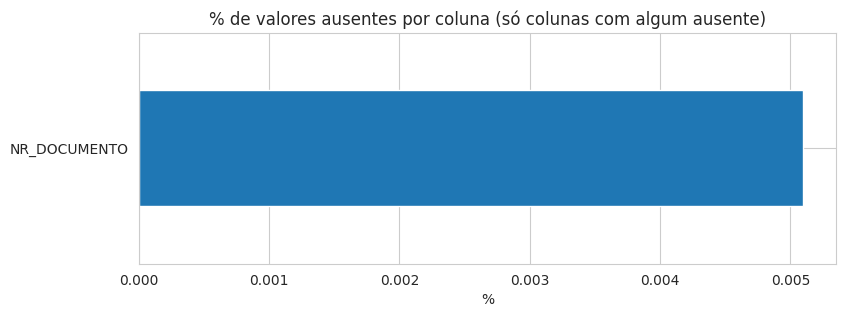

In [ ]:
#exibindo informações das colunas
print(f"{df_dc.shape[0]} registros despesas x {df_dc.shape[1]} colunas\n")
display(df_dc.dtypes.value_counts().rename('nº de colunas'))

faltantes = (df_dc.isna().mean() * 100).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    plt.figure(figsize=(9, max(3, len(faltantes) * 0.3)))
    faltantes.plot(kind='barh')
    plt.title('% de valores ausentes por coluna (só colunas com algum ausente)')
    plt.xlabel('%')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Nenhuma coluna com valores ausentes.")

In [ ]:
# Removendo Colunas que não serão usadas
df_dc = df_dc.drop(columns=['AA_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'CD_ELEICAO', 'DS_ELEICAO','SG_UE','NM_UE','CD_CARGO','DS_CARGO','NR_CPF_VICE_CANDIDATO','NR_PARTIDO','SG_PARTIDO','NM_PARTIDO','NM_FORNECEDOR','CD_ESFERA_PART_FORNECEDOR','DS_ESFERA_PART_FORNECEDOR','CD_MUNICIPIO_FORNECEDOR','NM_MUNICIPIO_FORNECEDOR','NR_CANDIDATO_FORNECEDOR', 'CD_CARGO_FORNECEDOR', 'DS_CARGO_FORNECEDOR', 'NR_PARTIDO_FORNECEDOR', 'SG_PARTIDO_FORNECEDOR', 'NM_PARTIDO_FORNECEDOR'])



In [ ]:
# exibindo todas as colunas após remoção
display(pd.DataFrame({"Coluna": df_dc.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,DT_ELEICAO
3,ST_TURNO
4,TP_PRESTACAO_CONTAS
5,DT_PRESTACAO_CONTAS
6,SQ_PRESTADOR_CONTAS
7,SG_UF
8,NR_CNPJ_PRESTADOR_CONTA
9,SQ_CANDIDATO


In [ ]:
#definindo as colunas categóricas e numéricas
colunas_numericas = [
    'VR_DESPESA_CONTRATADA',
]
colunas_numericas = [c for c in colunas_numericas if c in df_dc.columns]

colunas_categoricas = [
    'DS_TIPO_FORNECEDOR',
    'DS_ORIGEM_DESPESA',
]
colunas_categoricas = [c for c in colunas_categoricas if c in  df_dc.columns]

print("Numéricas:")
display(pd.DataFrame({"Coluna": colunas_numericas}))
print("Categóricas:")
display(pd.DataFrame({"Coluna": colunas_categoricas}))

Numéricas:


,Coluna
0,VR_DESPESA_CONTRATADA


Categóricas:


,Coluna
0,DS_TIPO_FORNECEDOR
1,DS_ORIGEM_DESPESA


Variáveis numéricas: distribuição e outliers


In [ ]:
display(df_dc[colunas_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
VR_DESPESA_CONTRATADA,"156,977.00","3,879.15","12,922.23",0.00,800.00,"1,621.00","3,000.00","1,352,000.00"


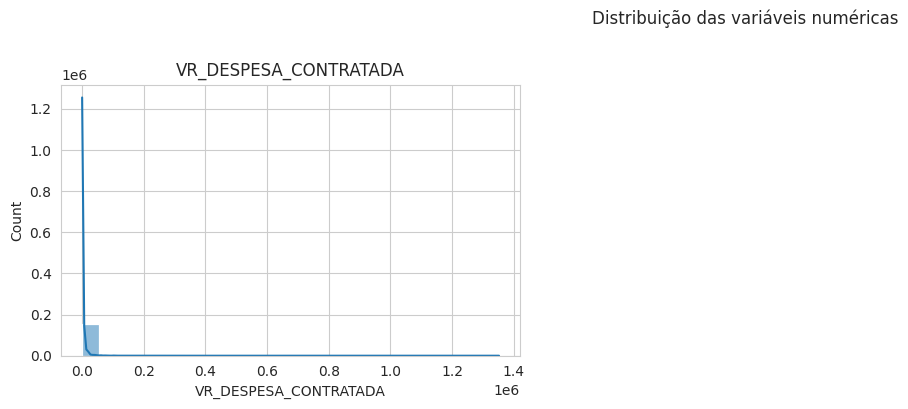

In [ ]:
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.histplot(df_dc[col], bins=25, ax=axes[i], kde='true')
    axes[i].set_title(col)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.01)
plt.tight_layout()
plt.show()

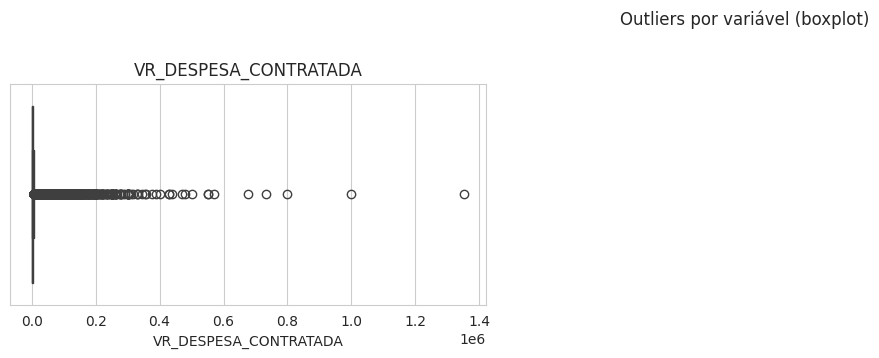

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_numericas):
    sns.boxplot(x=df_dc[col], ax=axes[i])
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variável (boxplot)', y=1.01)
plt.tight_layout()
plt.show()

### Quantificando os outliers (regra do IQR)

O boxplot mostra visualmente; esta tabela quantifica: quantos registros  (despesas) ficam fora do intervalo `[Q1 - 1.5·IQR, Q3 + 1.5·IQR]` na variável Despesa.

In [ ]:
linhas = []
for col in colunas_numericas:
    Q1, Q3 = df_dc[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf, lim_sup = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df_dc[col] < lim_inf) | (df_dc[col] > lim_sup)).sum()
    linhas.append({
        'variavel': col, 'limite_inferior': lim_inf, 'limite_superior': lim_sup,
        'qtd_outliers': n_outliers, 'pct_outliers': round(100 * n_outliers / len(df_dc), 1),
    })

pd.DataFrame(linhas).sort_values('pct_outliers', ascending=False)

,variavel,limite_inferior,limite_superior,qtd_outliers,pct_outliers
0,VR_DESPESA_CONTRATADA,"-2,500.00","6,300.00",16643,10.60


## Variáveis categóricas: contagens e proporções

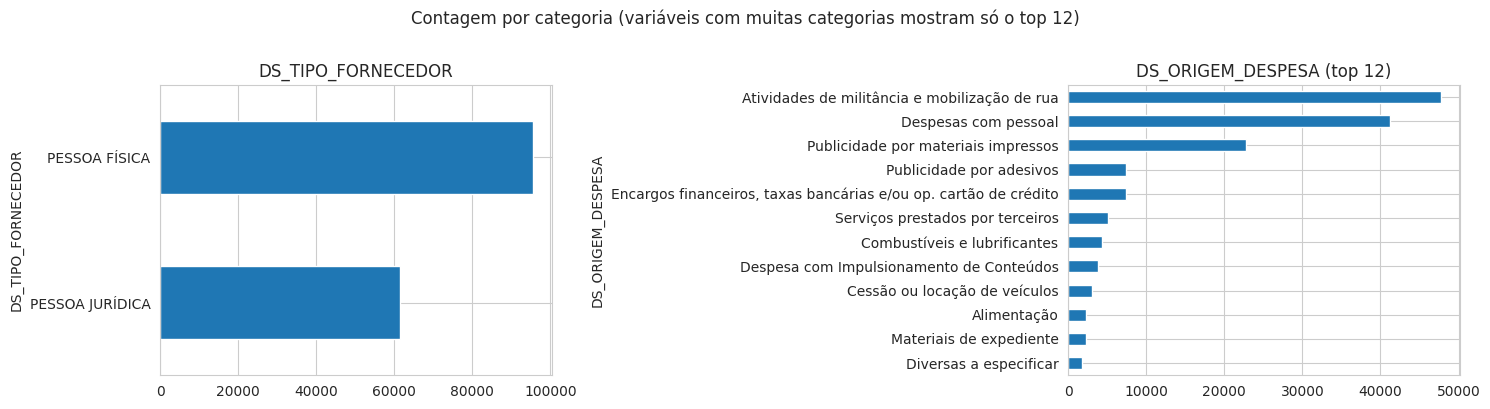

In [ ]:
def plot_categorica(ax, coluna, top_n=12):
    contagem = df_dc[coluna].value_counts().head(top_n)
    contagem.plot(kind='barh', ax=ax)
    ax.set_title(coluna + (f' (top {top_n})' if df_dc[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Contagem por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

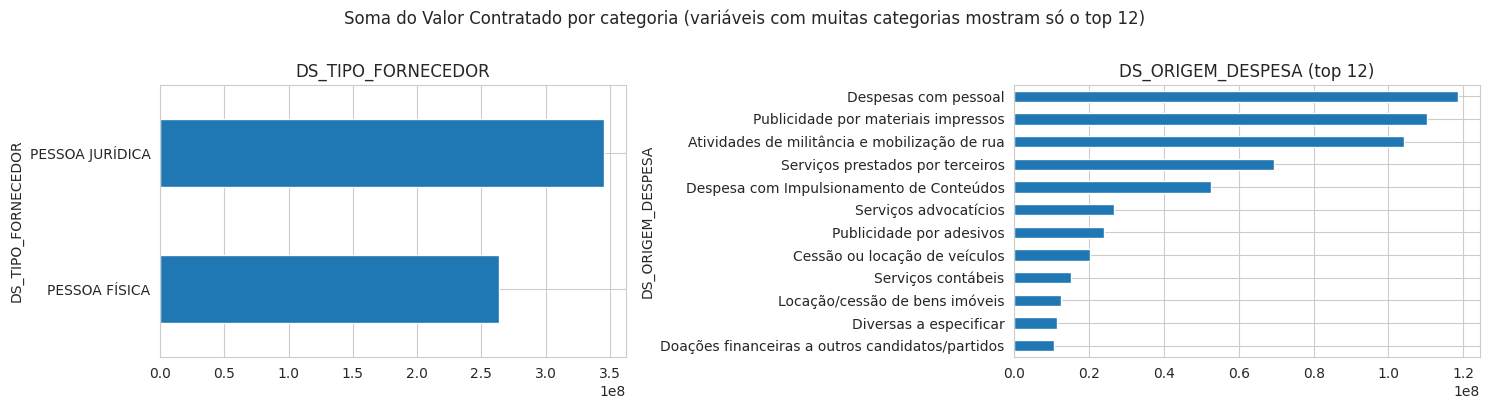

In [ ]:
def plot_soma_categorica(ax, coluna, top_n=12):
    # Agrupa pela categoria, soma os valores e pega os 12 maiores já ordenados
    soma = df_dc.groupby(coluna)['VR_DESPESA_CONTRATADA'].sum().nlargest(top_n)

    # Plota o gráfico de barras horizontais
    soma.plot(kind='barh', ax=ax)

    # Configura o título e inverte o eixo Y para a maior barra ficar no topo
    ax.set_title(coluna + (f' (top {top_n})' if df_dc[coluna].nunique() > top_n else ''))
    ax.invert_yaxis()

n = len(colunas_categoricas)
ncols = 2
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(colunas_categoricas):
    plot_soma_categorica(axes[i], col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Soma do Valor Contratado por categoria (variáveis com muitas categorias mostram só o top 12)', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# exibindo todas as colunas
display(pd.DataFrame({"Coluna": df_dc.columns}))

,Coluna
0,DT_GERACAO
1,HH_GERACAO
2,DT_ELEICAO
3,ST_TURNO
4,TP_PRESTACAO_CONTAS
5,DT_PRESTACAO_CONTAS
6,SQ_PRESTADOR_CONTAS
7,SG_UF
8,NR_CNPJ_PRESTADOR_CONTA
9,SQ_CANDIDATO


## Criando o DataFrame  e Exportando o CSV



In [ ]:
#Criando o DataFrame
df_dc_final = df_dc[['DT_GERACAO', 'HH_GERACAO', 'SQ_CANDIDATO',	'NR_CANDIDATO', 'DS_ORIGEM_DESPESA',	'SQ_DESPESA', 'DT_DESPESA', 'DS_DESPESA', 'VR_DESPESA_CONTRATADA']]

#caso queira fazer algum filtro final
#df_dc_final = df_dc_final[df_dc_final['VR_DESPESA_CONTRATADA'].between(0, 100000)].copy()

print(df_dc_final.shape)
df_dc_final[['DT_GERACAO', 'HH_GERACAO', 'SQ_CANDIDATO',	'NR_CANDIDATO', 'DS_ORIGEM_DESPESA',	'SQ_DESPESA', 'DT_DESPESA', 'DS_DESPESA', 'VR_DESPESA_CONTRATADA']].sample(min(5, len(df_dc_final )))

(156977, 9)


,DT_GERACAO,HH_GERACAO,SQ_CANDIDATO,NR_CANDIDATO,DS_ORIGEM_DESPESA,SQ_DESPESA,DT_DESPESA,DS_DESPESA,VR_DESPESA_CONTRATADA
12304,21/09/2026,04:29:13,250002537968,1045,Despesas com pessoal,74589917,06/09/2026,PRESTAÇÃO DE SERVIÇOS DE MOBILIZAÇÃO DE RUA NA...,"1,600.00"
719107,21/09/2026,04:29:13,130002534429,3000,"Encargos financeiros, taxas bancárias e/ou op....",74999539,08/09/2026,Tarifa Pix Enviado,0.50
713524,21/09/2026,04:29:13,130002543720,4000,Atividades de militância e mobilização de rua,74564474,09/09/2026,AGENTE DE MOBILIZAÇÃO E APOIO DE CAMPANHA,"2,000.00"
102321,21/09/2026,04:29:13,130002537202,1077,Atividades de militância e mobilização de rua,75056156,04/09/2026,CONTRATO DE PRESTACaO DE SERVICO CABO ELEITORAL,800.00
160827,21/09/2026,04:29:13,250002548513,1201,Diversas a especificar,74233307,02/09/2026,"BANDEIRA EM OXFORD 1,40 X 1,00",150.00


In [ ]:
#nome_uf = UF if UF is not None else 'BRASIL'
#nome_cargo = CARGO.replace(' ', '_')
#arquivo_saida = f"dados/despesas_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

#df_dc_final.to_csv(arquivo_saida, index=False)
#print(f"Dataset salvo em: {arquivo_saida}  ({df_dc_final.shape[0]} registros, {df_dc_final.shape[1]} colunas)")

Criando o DataFrame Final - Agrupado e Exportando o CSV

In [ ]:
df_dc_agrupado = df_dc.groupby(['SQ_CANDIDATO', 'DS_ORIGEM_DESPESA'])['VR_DESPESA_CONTRATADA'].sum().reset_index()
print(df_dc_agrupado.shape)
df_dc_agrupado[['SQ_CANDIDATO',	'DS_ORIGEM_DESPESA',	'VR_DESPESA_CONTRATADA']].sample(min(5, len(df_dc_final )))


(13163, 3)


,SQ_CANDIDATO,DS_ORIGEM_DESPESA,VR_DESPESA_CONTRATADA
2696,130002542018,Serviços próprios prestados por terceiros,"3,500.00"
570,80002549398,Serviços prestados por terceiros,"99,794.00"
5881,190002539358,Despesa com Impulsionamento de Conteúdos,"12,000.00"
12636,250002548499,Publicidade por materiais impressos,"3,850.00"
7726,250002530127,Publicidade por materiais impressos,"17,065.95"


In [ ]:
nome_uf = UF if UF is not None else 'BRASIL'
nome_cargo = CARGO.replace(' ', '_')
arquivo_saida = f"dados/despesas_{nome_cargo}_{nome_uf}_{ANO_ELEICAO}.csv"

df_dc_agrupado.to_csv(arquivo_saida, index=False)
print(f"Dataset salvo em: {arquivo_saida}  ({df_dc_agrupado.shape[0]} registros, {df_dc_agrupado.shape[1]} colunas)")

Dataset salvo em: dados/despesas_Deputado_Federal_('SP', 'RJ', 'MG', 'ES')_2026.csv  (13163 registros, 3 colunas)
